In [6]:
import pandas as pd
import numpy as np

import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,accuracy_score,recall_score,confusion_matrix,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [7]:
file_paths = [
    "/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_1.csv",
    "/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_10.csv",
     "/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_60.csv"
]

dfs = []
target_size = 500000  

for path in file_paths:
    df = pd.read_csv(path)
    

    if "category" in df.columns:
        df = df[df["category"] != "Normal"]
    
    
    df = df.head(target_size)
    

    cols_to_drop = ["pkSeqID", "stime", "ltime", "seq"]
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
    
    dfs.append(df)


df = pd.concat(dfs, ignore_index=True)
print("Merged dataset shape:", df.shape)
print(df["category"].value_counts())




/tmp/ipykernel_73/1899709718.py:11: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/tmp/ipykernel_73/1899709718.py:11: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Merged dataset shape: (1500000, 31)
category
Reconnaissance    500000
DoS               500000
DDoS              500000
Name: count, dtype: int64


In [8]:
#shuffle
df = df.sample(frac=1).reset_index(drop=True)
df.head(10)

,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,state,dur,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,e,tcp,192.168.100.147,59460,192.168.100.3,9804,2,120,RST,0.036252,...,1,1,60,60,27.584686,0.000000,0.0,1,Reconnaissance,Service_Scan
1,e s,tcp,192.168.100.148,1396.0,192.168.100.5,80.0,4,616,REQ,43.918709,...,4,0,616,0,0.068308,0.068308,0.0,1,DoS,TCP
2,eU,udp,192.168.100.150,55838,192.168.100.7,5632,1,60,INT,0.000059,...,1,0,60,0,0.000000,0.000000,0.0,1,Reconnaissance,Service_Scan
3,e s,tcp,192.168.100.149,3658.0,192.168.100.7,80.0,5,770,REQ,57.235752,...,5,0,770,0,0.069886,0.069886,0.0,1,DoS,TCP
4,e,tcp,192.168.100.148,40850.0,192.168.100.3,47886.0,2,120,RST,0.002897,...,1,1,60,60,345.184692,0.000000,0.0,1,Reconnaissance,Service_Scan
5,e,tcp,192.168.100.148,5848.0,192.168.100.3,3557,2,120,RST,0.000051,...,1,1,60,60,19607.843750,0.000000,0.0,1,Reconnaissance,Service_Scan
6,e,udp,192.168.100.147,8612,192.168.100.3,80,12,720,INT,16.573908,...,12,0,720,0,0.663694,0.663694,0.0,1,DDoS,UDP
7,e,icmp,192.168.100.3,0x0303,192.168.100.147,0x2b9b,1,70,URP,0.000000,...,1,0,70,0,0.000000,0.000000,0.0,1,Reconnaissance,Service_Scan
8,e,tcp,192.168.100.150,56304,192.168.100.3,64816,2,120,RST,0.015584,...,1,1,60,60,64.168373,0.000000,0.0,1,Reconnaissance,Service_Scan
9,e,tcp,192.168.100.150,56304,192.168.100.3,52908,2,120,RST,0.039259,...,1,1,60,60,25.471865,0.000000,0.0,1,Reconnaissance,Service_Scan


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pkts,1500000.0,5.903823,10.278016,1.0,2.000000,5.000000,9.000000,4.879000e+03
bytes,1500000.0,511.789559,5759.555879,60.0,120.000000,522.000000,660.000000,2.536017e+06
dur,1500000.0,20.698602,33.103954,0.0,0.028176,15.586910,38.349766,1.716233e+03
mean,1500000.0,1.197912,1.605446,0.0,0.000142,0.037325,2.869080,4.878934e+00
stddev,1500000.0,0.463678,0.690166,0.0,0.000000,0.008630,1.021309,2.499505e+00
smac,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dmac,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sum,1500000.0,3.924058,5.230167,0.0,0.000143,0.048372,10.590330,4.583837e+01
min,1500000.0,0.581048,1.104405,0.0,0.000000,0.000380,0.143438,4.869134e+00
max,1500000.0,1.639819,2.105297,0.0,0.000143,0.047686,4.240499,4.999999e+00


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 31 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   flgs          1500000 non-null  object 
 1   proto         1500000 non-null  object 
 2   saddr         1500000 non-null  object 
 3   sport         1499787 non-null  object 
 4   daddr         1500000 non-null  object 
 5   dport         1499787 non-null  object 
 6   pkts          1500000 non-null  int64  
 7   bytes         1500000 non-null  int64  
 8   state         1500000 non-null  object 
 9   dur           1500000 non-null  float64
 10  mean          1500000 non-null  float64
 11  stddev        1500000 non-null  float64
 12  smac          0 non-null        float64
 13  dmac          0 non-null        float64
 14  sum           1500000 non-null  float64
 15  min           1500000 non-null  float64
 16  max           1500000 non-null  float64
 17  soui          0 non-null   

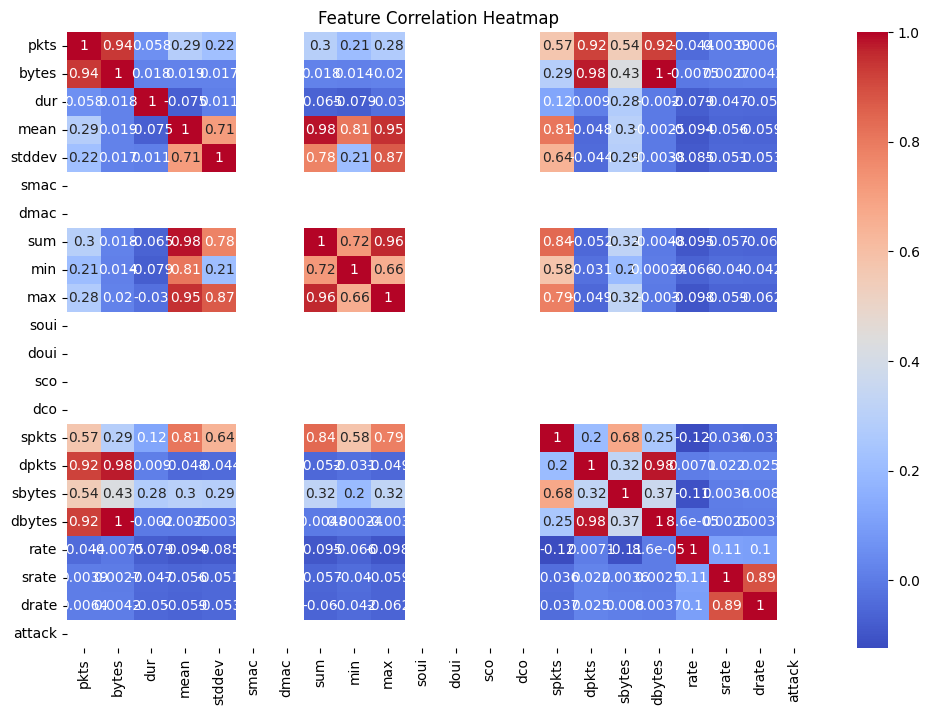

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


corr_matrix = df.corr(numeric_only=True)


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)

plt.title("Feature Correlation Heatmap")
plt.show()  

In [12]:
import requests

def get_location(ip):
    try:
        res = requests.get(f"http://ip-api.com/json/{ip}", timeout=5).json()
        return pd.Series([res.get('lat'), res.get('lon'), res.get('country')])
    except:
        return pd.Series([None, None, None])

# نطبق على عدد صغير (عشان السرعة)
sample_df = df[['saddr']].drop_duplicates().head(100)

sample_df[['lat', 'lon', 'country']] = sample_df['saddr'].apply(get_location)

print(sample_df.head())

             saddr   lat   lon country
0  192.168.100.147  None  None    None
1  192.168.100.148  None  None    None
2  192.168.100.150  None  None    None
3  192.168.100.149  None  None    None
7    192.168.100.3  None  None    None


In [ ]:
print(sample_df['saddr'].head(20))

In [2]:
!pip install folium
import folium

# نبدأ الخريطة
map = folium.Map(location=[20,0], zoom_start=2)

# نحط نقاط
for _, row in sample_df.iterrows():
    if pd.notnull(row['lat']):
        folium.Marker(
            location=[row['lat'], row['lon']],
            popup=row['country']
        ).add_to(map)

map

NameError: name 'sample_df' is not defined

In [7]:
df=df.drop(['smac','dmac','sco','dco','saddr','soui','doui','daddr','attack','subcategory '],axis=1)

In [8]:
df.columns

Index(['flgs', 'proto', 'sport', 'dport', 'pkts', 'bytes', 'state', 'dur',
       'mean', 'stddev', 'sum', 'min', 'max', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'srate', 'drate', 'category'],
      dtype='object')

In [9]:
df=df.drop_duplicates()

In [10]:
df.isnull().sum()

flgs          0
proto         0
sport       208
dport       208
pkts          0
bytes         0
state         0
dur           0
mean          0
stddev        0
sum           0
min           0
max           0
spkts         0
dpkts         0
sbytes        0
dbytes        0
rate          0
srate         0
drate         0
category      0
dtype: int64

In [ ]:
!pip install folium
import folium

# نبدأ الخريطة
map = folium.Map(location=[20,0], zoom_start=2)

# نحط نقاط
for _, row in sample_df.iterrows():
    if pd.notnull(row['lat']):
        folium.Marker(
            location=[row['lat'], row['lon']],
            popup=row['country']
        ).add_to(map)

map

In [ ]:
df=df.dropna(subset=['sport','dport'])

In [ ]:
cols_to_convert = ['sport', 'dport']
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce').astype('Int64')

In [ ]:
df.info()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


num_cols = df.select_dtypes(include='number')


num_cols = num_cols.drop(columns=['dport','sport'], errors='ignore')


skew_vals = num_cols.skew()
print("Skew before transformation:\n")
for col, skew_val in skew_vals.items():
    print(f"{col}: {skew_val:.4f}")

skewed_cols = skew_vals[abs(skew_vals) > 1].index

for col in skewed_cols:
    df[col] = np.log1p(df[col])


new_skew_vals = df[num_cols.columns].skew()
print("\nSkew after transformation:\n")
for col, skew_val in new_skew_vals.items():
    print(f"{col}: {skew_val:.4f}")


skew_vals_dict = new_skew_vals.to_dict()

skew_df = pd.DataFrame(list(skew_vals_dict.items()), columns=['Column', 'Skew'])


colors = []
for val in skew_df['Skew']:
    if abs(val) > 1.5:
        colors.append('red')
    elif abs(val) > 1:
        colors.append('orange')
    else:
        colors.append('green')


plt.figure(figsize=(12,6))
plt.bar(skew_df['Column'], skew_df['Skew'], color=colors)
plt.xticks(rotation=45)
plt.title('Skewness of All Numeric Columns (After Log Transform, Excluding Ports)')
plt.axhline(1, color='gray', linestyle='--', label='Skew = 1')
plt.axhline(-1, color='gray', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#the relationships between protocol type and attack category
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)
sns.countplot(x='proto', hue='category', data=df)
plt.title("Countplot of Protocol by Category")
plt.xlabel("Protocol")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
heatmap_data = pd.crosstab(df['proto'], df['category'])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.ylabel("Protocol")
plt.xlabel("Attack Category")
plt.title("Heatmap of Protocol vs Attack Category")

plt.tight_layout()
plt.show()

In [ ]:
#لما عدد الباكتس وحجمهم كبر احتمالية حدوث الكونسينس كبيرة
plt.figure(figsize=(8,5))
sns.scatterplot(x='pkts', y='bytes', hue='category', data=df, alpha=0.4)



plt.title("Packets vs Bytes by Category")
plt.xlabel("Number of Packets")
plt.ylabel("Bytes")
plt.show()



In [ ]:
#relationships between flags and attack category
plt.figure(figsize=(14,6))
ax = sns.countplot(x='flgs', hue='category', data=df)



plt.title("Count of Flags by Attack Category (Log Scale)") 
plt.xlabel("Flags")
plt.ylabel("Count (log scale)")
plt.show()

In [ ]:
#الاكثر سرعة في ارسال البينانات ريكونسينس وكمان معدل ارساله مش ثابت
#على عكس ان dos , ddos بيكون وقتهم ثابت ايا كان نوع الهدف او المهمة
plt.figure(figsize=(12,6))
sns.scatterplot(x='dur', y='rate', hue='category', data=df, alpha=0.7)
plt.title("Rate vs Duration colored by Attack Category")
plt.xlabel("Duration (seconds)")
plt.ylabel("Rate(bytes/sec)")
plt.legend(title='Attack Category')
plt.show()

In [ ]:
diff_bytes=abs(df['sbytes'] - df['dbytes'])

In [ ]:

 #بيتبعت باكتس كتيرة اوي من السورس اكتر من اللي لازم تستلمها المستقبلل ddos attack#
plt.figure(figsize=(8,5))
sns.barplot(x=df['category'],y=diff_bytes, alpha=0.6)
plt.title('Packets vs Bytes by Category')
plt.xlabel('difference between source and destination packets')
plt.ylabel('attack')

plt.show()

In [ ]:
import matplotlib.pyplot as plt

categories = df['category'].unique()

plt.figure(figsize=(20, 10))

for i, cat in enumerate(categories):
    plt.subplot(1, len(categories), i+1)

    state_counts = df[df['category'] == cat]['state'].value_counts()

    state_counts = state_counts[state_counts / state_counts.sum() > 0.01]

    colors = plt.cm.Set3.colors[:len(state_counts)]

    plt.pie(
        state_counts,
        labels=state_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        pctdistance=0.8,
        labeldistance=1.1,
        textprops={'fontsize': 10}
    )

    plt.title(f"States for {cat}", pad=20)

plt.tight_layout()
plt.show()

In [ ]:
df.head(20)

In [ ]:
import pandas as pd


numeric_cols = df.select_dtypes(include='number')  # only numeric columns


range_df = pd.DataFrame({
    'min': numeric_cols.min(),
    'max': numeric_cols.max()
})

print(range_df)

In [ ]:

def port_to_group(port):
    if 0 <= port <= 1023:
        return 'Well‑Known'
    elif 1024 <= port <= 49151:
        return 'Registered Ports'
    elif 49152 <= port <= 65535:
        return 'Dynamic / Private Ports'
    else:
        return 'Custom / Non‑standard'

df['dport'] =df['dport'].apply(port_to_group)
df['sport'] =df['sport'].apply(port_to_group)

print(df['dport'].head())
print(df['sport'].head())


In [ ]:
port_counts = df.groupby(['category', 'dport']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=port_counts, x='dport', y='count', hue='category', palette='viridis')
plt.title('Relation between dport groups and Category')
plt.xlabel('Destination Port Group')
plt.ylabel('Count')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

#### model

In [ ]:
x=df.drop('category' , axis=1)
y=df['category']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8 , random_state=42)

In [ ]:
x_train['flgs'].value_counts()

In [ ]:
threshold = 1000


rare_states = x_train['state'].value_counts()[x_train['state'].value_counts() < threshold].index

x_train['state'] = x_train['state'].replace(rare_states, 'Other')
x_test['state'] = x_test['state'].replace(rare_states, 'Other')



rare_flgs = x_train['flgs'].value_counts()[x_train['flgs'].value_counts() < threshold].index

x_train['flgs'] = x_train['flgs'].replace(rare_flgs, 'Other')
x_test['flgs'] = x_test['flgs'].replace(rare_flgs, 'Other')

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()  


num_cols = x_train.select_dtypes(include='number').columns


x_train[num_cols] = scaler.fit_transform(x_train[num_cols])


x_test[num_cols] = scaler.transform(x_test[num_cols])


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder


cat_cols = x_train.select_dtypes(include='object').columns.tolist()


encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)


x_train[cat_cols] = encoder.fit_transform(x_train[cat_cols])


x_test[cat_cols] = encoder.transform(x_test[cat_cols])


print(x_train.head())
print(x_test.head())

In [ ]:
!pip install pca

In [ ]:
from pca import pca
pca_model = pca(normalize=True) 
out = pca_model.fit_transform(x_train)


#fig,ax = pca_model.plot()

In [ ]:
topfeat = pd.DataFrame(out['topfeat'])
topfeat

In [ ]:
cols = list(topfeat[topfeat['type']=='best']['feature'])
x_train=x_train[cols]
x_train

In [ ]:
cols = list(topfeat[topfeat['type']=='best']['feature'])
x_test=x_test[cols]
x_test

## Modling

1. Logistic with different Hyperparameters

In [ ]:
best_results = {}

3. Random Forest with different Hyperparameters

In [ ]:

random_forest_hyperparameters  = [
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'gini'},
   
]

In [ ]:
final_accuracies = []
best_rf_accuracy = 0
best_rf_params = None
y_pred_rff= None
for params in random_forest_hyperparameters:
    RF = RandomForestClassifier(random_state=42, **params)
    RF.fit(x_train, y_train)
    y_pred_rf = RF.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred_rf)
    if accuracy > best_rf_accuracy:
        best_rf_accuracy = accuracy
        best_rf_params = params
        y_pred_rff=y_pred_rf
    final_accuracies.append((params, accuracy))

In [ ]:
best_results['Random Forest'] = {
    'best_params': best_rf_params,
    'accuracy': best_rf_accuracy
}

In [ ]:
y_pred_train = RF.predict(x_train)
y_pred_test = RF.predict(x_test)
accuracy_score(y_test, y_pred_test),accuracy_score(y_train, y_pred_train),

In [ ]:
x_train.shape, x_test.shape

In [ ]:
# Evaluate the Random Forest model
evaluate_model(y_test, y_pred_rff, model_name="Random Forest")